## CSCI-4041 - Algorithms - Chapter 11 - Hash Maps

### Joy Upton Azzam

### 3/14/2026

<mark>_____________________________________________________________________________________</mark>

## Chain Hash Map

The following python class ```chainhashmap``` was implemented using the singly linked-list class ```linkedlist``` from chapter 10. The code for ```chainhashmap``` is my implementation based on the brief description below from page 278 in chapter 11 of the CLRS textbook.

<div style="width:33%; margin: auto;">
    
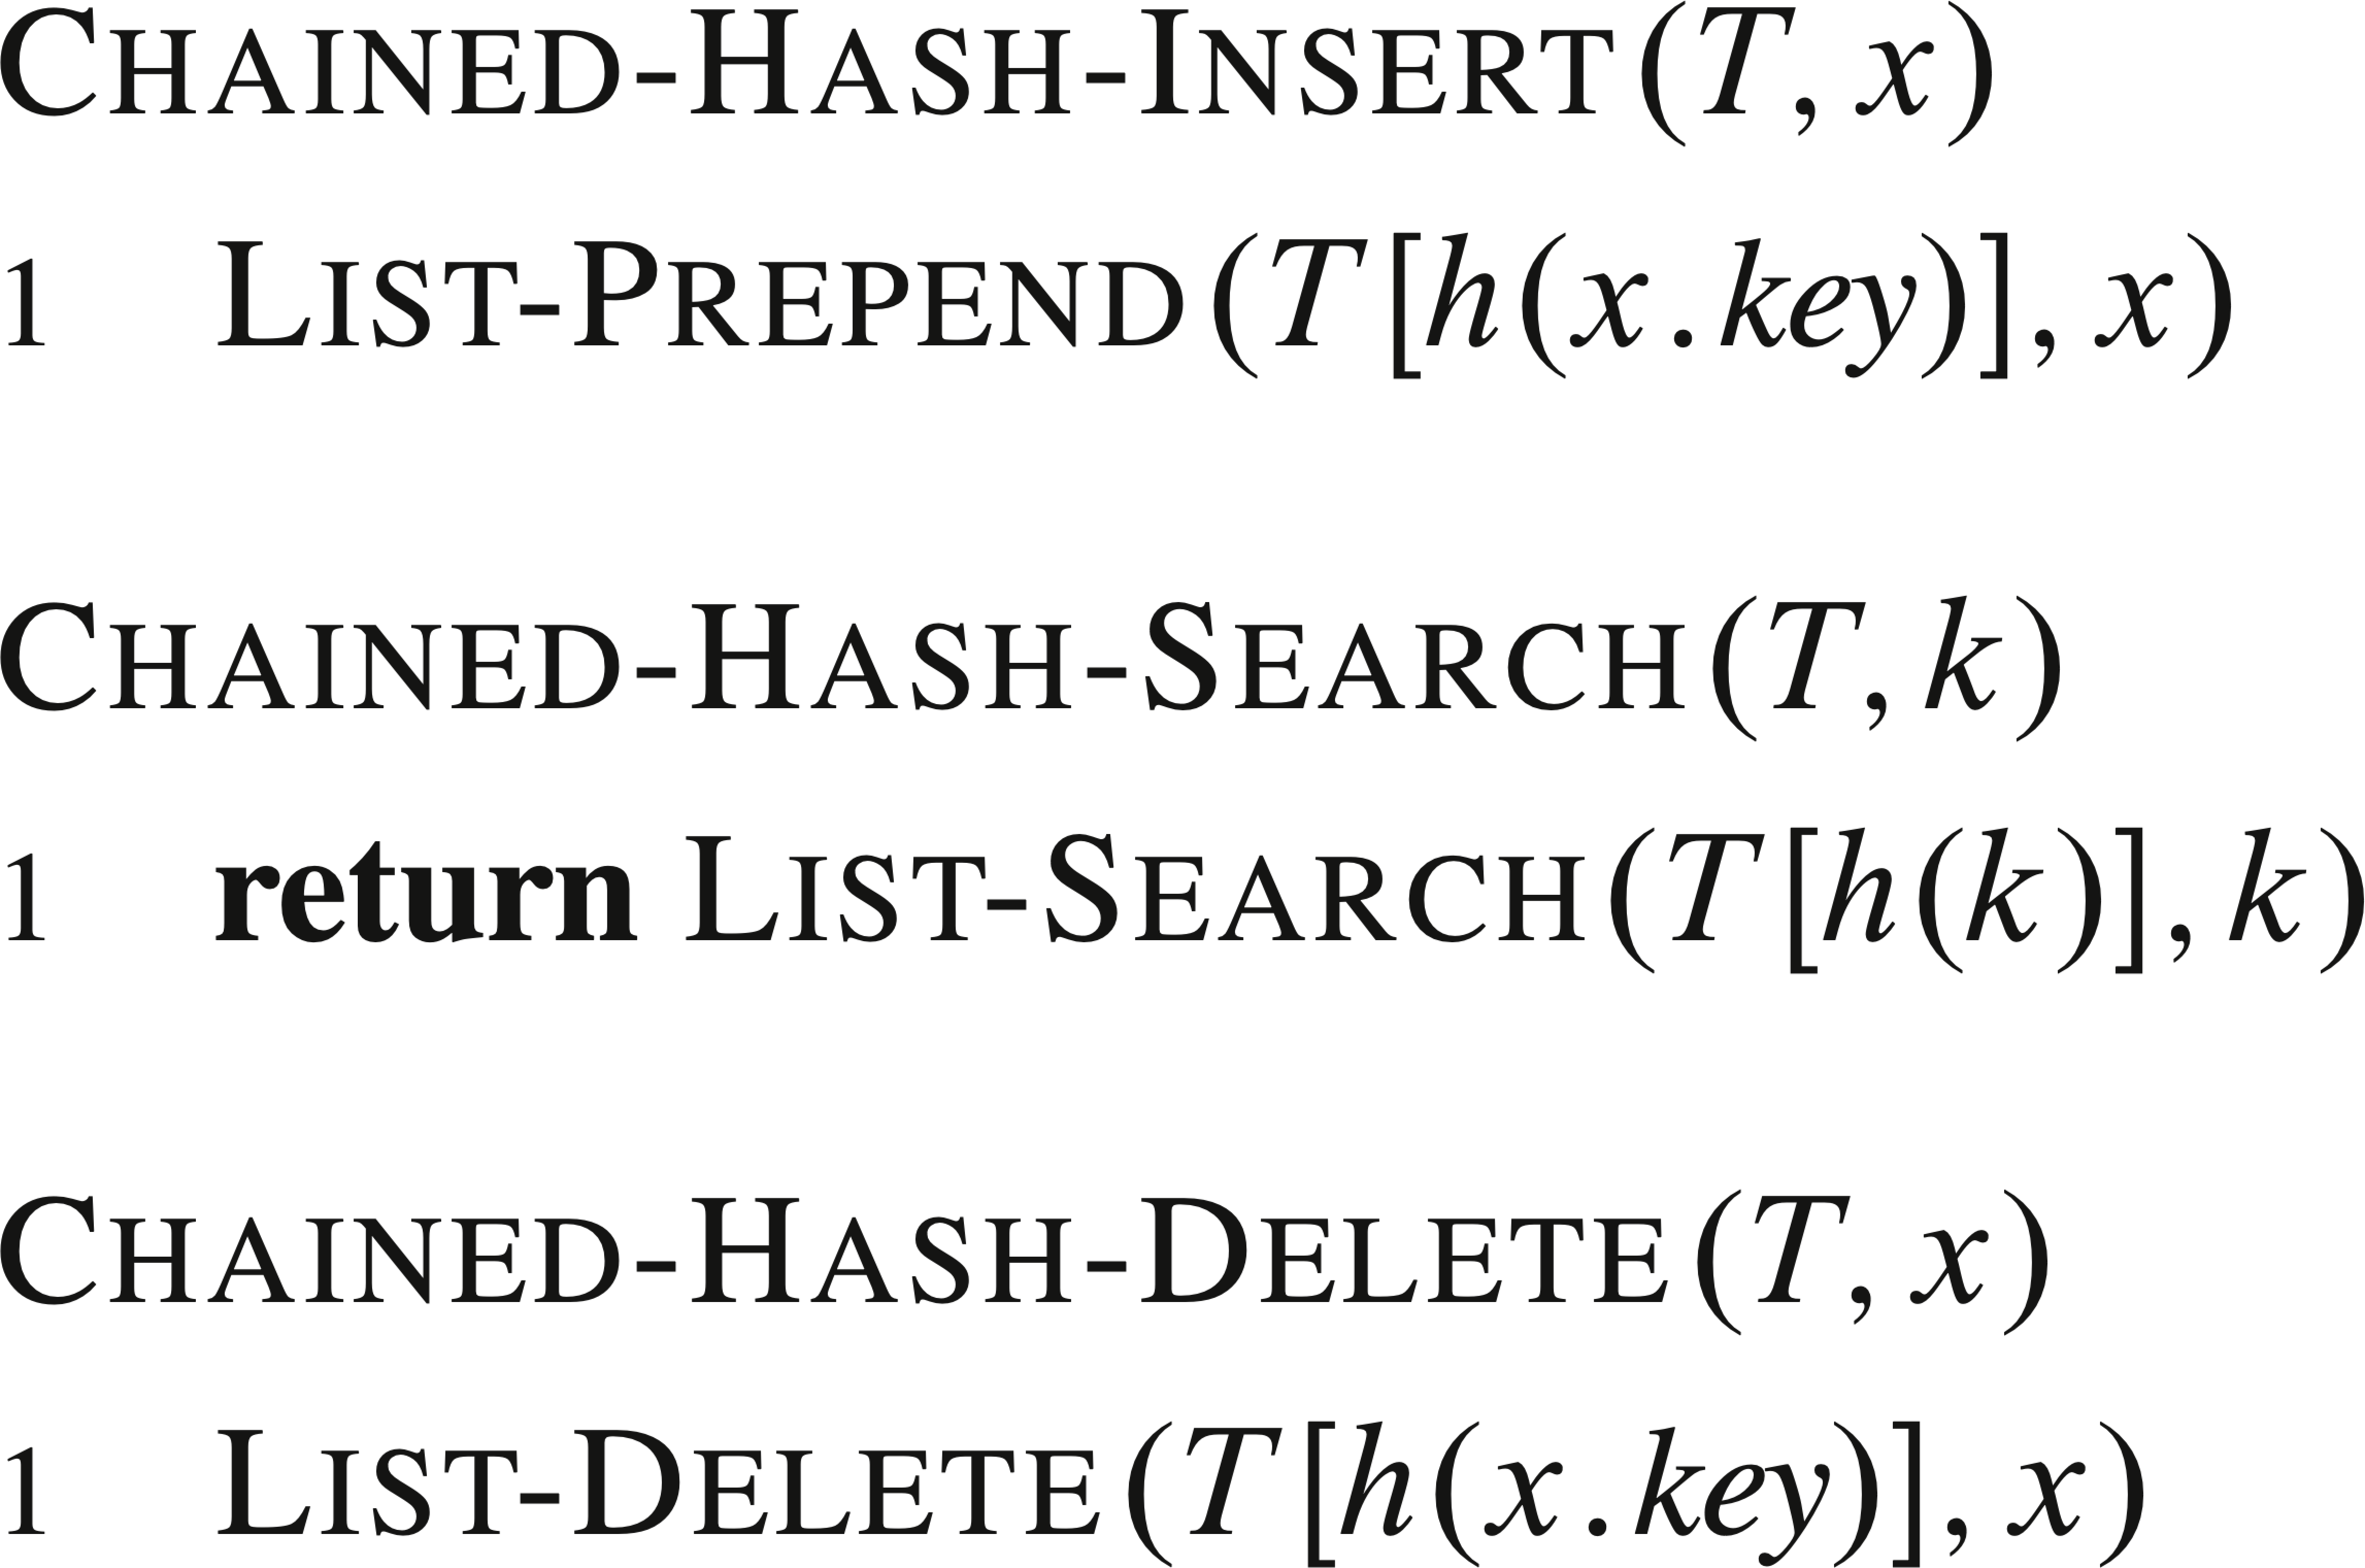

</div>

### 1. Load the Linked List class from Chapter 10

In [3]:
%%capture
%run Ch10_LinkedLists.ipynb

<mark>_____________________________________________________________________________________</mark>

### 2. Chain Hash Map

In [7]:
class chainhashmap:
    """a hash map which implements separate chaining collision resolution"""
    
    ################################################################ nested item class
    class item:
        """items for the table"""
        
        def __init__(self,key,value):
            self.key = key
            self.value = value
        
        def __eq__(self,other):
            """comparison of item objects based on key attribute"""    
            return self.key == other.key
        
        def __ne__(self,other):
            """comparison of item objects based on key attribute"""    
            if type(other)==str:
                return self.key != other
            else:
                return self.key != other.key
        
        def __str__(self):
            """printing utility"""
            return "("+str(self.key)+","+str(self.value)+")"
    ################################################################
    
    
    def __init__(self,capacity=11):
        """constructor for table hash map with m max slots"""
        self.m = capacity                                     # table size
        self.table = [linkedlist() for i in range(capacity)]  # initialize with empty lists
    
    def h(self,key):
        """hash function for map -using python hash and division method"""
        return hash(key) % self.m
    
    def insert(self,x):
        """insert record x into the table"""
        L = self.table[self.h(x.key)]     # extract appropriate linked-list
        node = L.search(x.key)            # check for existing key
        if node:
            item = node.key               # extract existing item
            if item.key == x.key:
                item.value = x.value      # update existing value in table
        else:
            L.prepend(x)                  # insert new item in table

    def search(self,key):
        """search the table for key"""
        L = self.table[self.h(key)]       # extract appropriate linked-list
        node = L.search(key)              # call linked-list search for key
        if node:
            item = node.key               # extract item from node
            return item                   # return item
        else:
            return None                   # key not found
    
    def delete(self,x):
        """delete item x from the table"""
        L = self.table[self.h(x.key)]     # extract linked-list
        L.delete(x)                       # delete item from list
    
    def __str__(self):
        """printing utility for chain hash map"""
        out = ""
        for ll in M.table:
            out += str(ll) + "\n"
        return out

<mark>_____________________________________________________________________________________</mark>

### 3. Testing

#### (a) contstructor usage

In [12]:
M = chainhashmap()

#### (b) insert and __str__ (print) usage

In [15]:
x = chainhashmap.item("Apple",7)
M.insert(x)
print(M)

[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[(Apple,7)]
[ ]



In [17]:
x = chainhashmap.item("Banana",3)
M.insert(x)
print(M)

[ ]
[(Banana,3)]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[(Apple,7)]
[ ]



In [19]:
x = chainhashmap.item("Orange",12)
M.insert(x)
print(M)

[ ]
[(Banana,3)]
[ ]
[ ]
[ ]
[ ]
[(Orange,12)]
[ ]
[ ]
[(Apple,7)]
[ ]



In [21]:
x = chainhashmap.item("Pear",6)
M.insert(x)
print(M)

[(Pear,6)]
[(Banana,3)]
[ ]
[ ]
[ ]
[ ]
[(Orange,12)]
[ ]
[ ]
[(Apple,7)]
[ ]



In [23]:
x = chainhashmap.item("Grapes",3)
M.insert(x)
print(M)

[(Pear,6)]
[(Banana,3)]
[ ]
[ ]
[ ]
[ ]
[(Orange,12)]
[ ]
[ ]
[(Grapes,3), (Apple,7)]
[ ]



In [25]:
x = chainhashmap.item("Grapes",22)
M.insert(x)
print(M)

[(Pear,6)]
[(Banana,3)]
[ ]
[ ]
[ ]
[ ]
[(Orange,12)]
[ ]
[ ]
[(Grapes,22), (Apple,7)]
[ ]



#### (c) search usage

In [28]:
x = M.search("Pear")
print(x)

(Pear,6)


In [30]:
x2 = M.search("Pineapple")
print(x2)

None


#### (d) delete usage

In [33]:
print(M)
print("deleting key =",x.key,"from the table")
M.delete(x)
print(M)

[(Pear,6)]
[(Banana,3)]
[ ]
[ ]
[ ]
[ ]
[(Orange,12)]
[ ]
[ ]
[(Grapes,22), (Apple,7)]
[ ]

deleting key = Pear from the table
[ ]
[(Banana,3)]
[ ]
[ ]
[ ]
[ ]
[(Orange,12)]
[ ]
[ ]
[(Grapes,22), (Apple,7)]
[ ]



In [35]:
x3 = M.search("Banana")
print(x3)

(Banana,3)


In [37]:
print(M)
print("deleting key =",x3.key,"from the table")
M.delete(x3)
print(M)

[ ]
[(Banana,3)]
[ ]
[ ]
[ ]
[ ]
[(Orange,12)]
[ ]
[ ]
[(Grapes,22), (Apple,7)]
[ ]

deleting key = Banana from the table
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[(Orange,12)]
[ ]
[ ]
[(Grapes,22), (Apple,7)]
[ ]



<mark>_____________________________________________________________________________________</mark>

### 4. Additional Testing Tools

In [41]:
import random

def rand_key(n=3):
    """returns a random string of length 3"""
    out = ""
    for i in range(n):
        out += chr(random.randint(ord('A'),ord('Z')))
    return out

In [43]:
for i in range(10):
    print(rand_key())

MIO
KEE
QKW
TJY
QDM
ODC
ZDD
CKC
ZLS
OYY


<mark>_____________________________________________________________________________________</mark>

### 5. Randomized Chain Hash Map Tests

In [47]:
M = chainhashmap()

KEYS = []
for i in range(10):
    x = chainhashmap.item(rand_key(),random.randrange(99))
    KEYS.append(x.key)
    M.insert(x)
print(M)
print(KEYS)

[(FEW,18), (DDT,65), (TVO,69), (HSD,89)]
[ ]
[(BPQ,6)]
[ ]
[ ]
[(TRH,74), (VZC,97)]
[(NLW,42)]
[(CAD,54)]
[(CML,79)]
[ ]
[ ]

['HSD', 'TVO', 'VZC', 'DDT', 'TRH', 'CAD', 'NLW', 'CML', 'BPQ', 'FEW']


In [49]:
for key in KEYS:
    x = M.search(key) # extract item
    M.delete(x)       # delete item
    print(M)          # print modified table

[(FEW,18), (DDT,65), (TVO,69)]
[ ]
[(BPQ,6)]
[ ]
[ ]
[(TRH,74), (VZC,97)]
[(NLW,42)]
[(CAD,54)]
[(CML,79)]
[ ]
[ ]

[(FEW,18), (DDT,65)]
[ ]
[(BPQ,6)]
[ ]
[ ]
[(TRH,74), (VZC,97)]
[(NLW,42)]
[(CAD,54)]
[(CML,79)]
[ ]
[ ]

[(FEW,18), (DDT,65)]
[ ]
[(BPQ,6)]
[ ]
[ ]
[(TRH,74)]
[(NLW,42)]
[(CAD,54)]
[(CML,79)]
[ ]
[ ]

[(FEW,18)]
[ ]
[(BPQ,6)]
[ ]
[ ]
[(TRH,74)]
[(NLW,42)]
[(CAD,54)]
[(CML,79)]
[ ]
[ ]

[(FEW,18)]
[ ]
[(BPQ,6)]
[ ]
[ ]
[ ]
[(NLW,42)]
[(CAD,54)]
[(CML,79)]
[ ]
[ ]

[(FEW,18)]
[ ]
[(BPQ,6)]
[ ]
[ ]
[ ]
[(NLW,42)]
[ ]
[(CML,79)]
[ ]
[ ]

[(FEW,18)]
[ ]
[(BPQ,6)]
[ ]
[ ]
[ ]
[ ]
[ ]
[(CML,79)]
[ ]
[ ]

[(FEW,18)]
[ ]
[(BPQ,6)]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]

[(FEW,18)]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]

[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]
[ ]

